In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils

import lal

%matplotlib widget

# Only needed on Apple M4 with numpy<2.3 https://github.com/numpy/numpy/issues/28687
# (still, ok on other systems)
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

In [2]:
def _generate_injection_dic(seed):
    aux_prior = cogwheel.gw_prior.IASPrior(
        f_ref=100.0,
        mchirp_range=(10, 50),
        detector_pair='HL',
        tgps=0,
        ref_det_name='H',
        f_avg=100.0,
        d_hat_max=100.0,
        dt0=10,
    )
    injection_dic = dict(
        aux_prior.generate_random_samples(1, seed=seed).loc[0, aux_prior.standard_params])
    return injection_dic


def get_event_data(seed=0):
    """Return an EventData with a secret injection in it."""
    injection_dic = _generate_injection_dic(seed)

    asd_funcs = ['asd_H_O3', 'asd_L_O3', 'asd_V_O3']  # pinned: see build_and_run_notebook.py

    eventname = f'GW{seed}'
    event_data = cogwheel.data.EventData.gaussian_noise(
        eventname, duration=128.0, detector_names='HLV', fmax=512.0,
        asd_funcs=asd_funcs, tgps=0.0, seed=seed)

    event_data.inject_signal(par_dic=injection_dic, approximant='IMRPhenomXODE')

    return event_data


event_data = get_event_data()

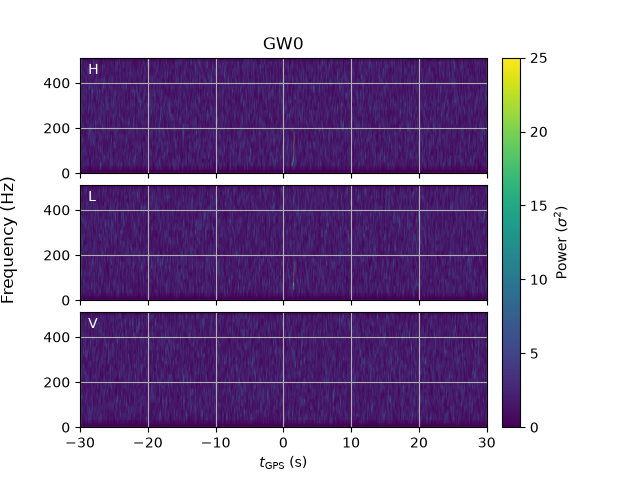

In [3]:
xlim = (-30, 30)  # Edit this
event_data.specgram(xlim=xlim);

In [4]:
t_merger_guess = 1.6

In [5]:
whitened_td = event_data.get_whitened_td()

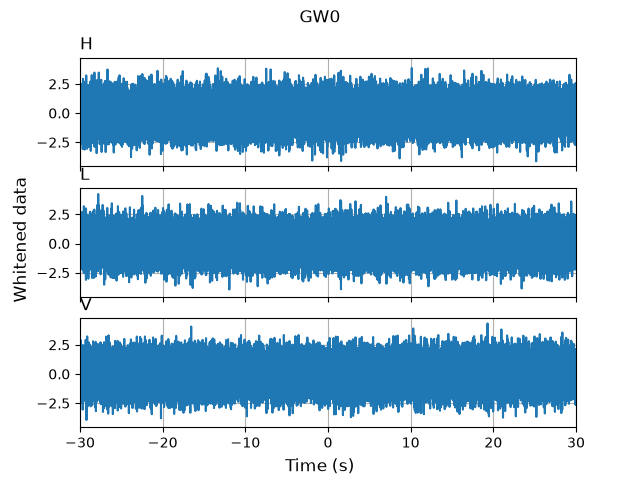

In [6]:
fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for det_name, ax, wht_strain in zip(event_data.detector_names, axs, whitened_td):
    ax.plot(event_data.times - event_data.tcoarse, wht_strain)
    ax.grid()
    ax.set_title(det_name, loc='left')

ax.set_xlim(xlim)
fig.supxlabel('Time (s)')
fig.supylabel('Whitened data')
fig.suptitle(event_data.eventname);

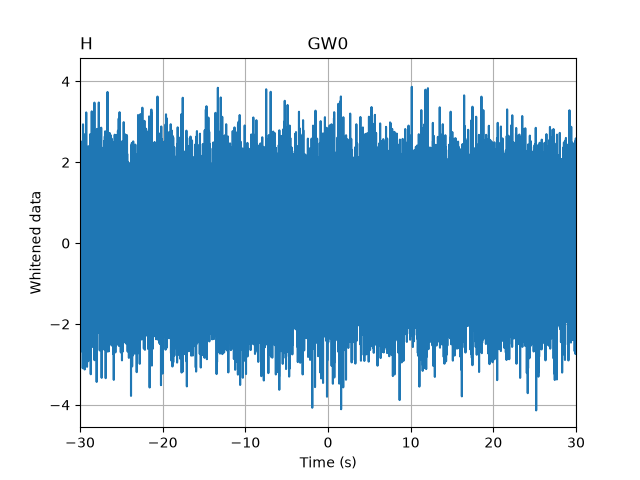

In [7]:
# The same but just one detector
i_det = 0
det_name = event_data.detector_names[i_det]
wht_strain = whitened_td[i_det]
plt.figure()
plt.plot(event_data.times - event_data.tcoarse, wht_strain)
plt.grid()
plt.title(det_name, loc='left')

plt.xlim(xlim)
plt.xlabel('Time (s)')
plt.ylabel('Whitened data')
plt.title(event_data.eventname);

In [8]:
lal.MTSUN_SI

4.925490947641267e-06

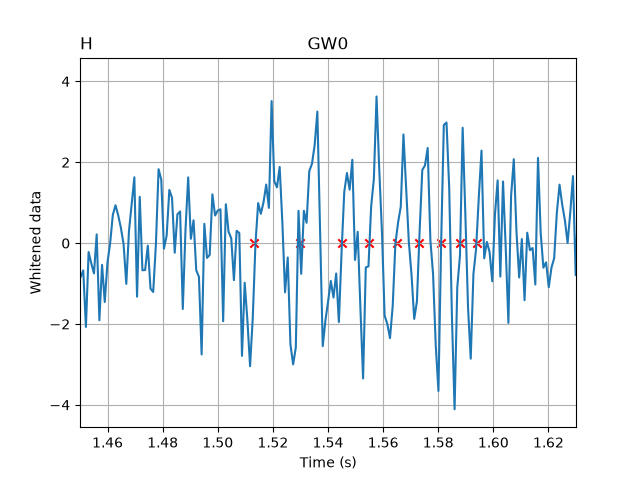

In [9]:
i_det = 0
xlim = 1.45, 1.63

det_name = event_data.detector_names[i_det]
wht_strain = whitened_td[i_det]

plt.figure()
plt.plot(event_data.times - event_data.tcoarse, wht_strain)
plt.grid()
plt.title(det_name, loc='left')

plt.xlim(xlim)
plt.xlabel('Time (s)')
plt.ylabel('Whitened data')
plt.title(event_data.eventname)

ascending_zero_crossings = 1.513, 1.53, 1.545, 1.555, 1.565, 1.573, 1.581, 1.588, 1.594
plt.scatter(ascending_zero_crossings, [0] * len(ascending_zero_crossings), c='r', marker='x')

In [10]:
periods = np.diff(ascending_zero_crossings)
times = np.add(ascending_zero_crossings[:-1], ascending_zero_crossings[1:]) / 2
frequencies = 1 / periods

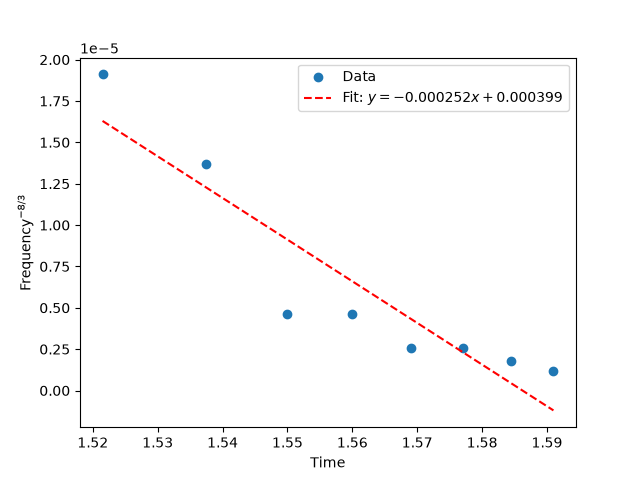

In [11]:
y = frequencies**(-8/3)
x = times

# Perform linear fit
slope, const = np.polyfit(times, y, deg=1)

# Generate fitted line for plotting
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = slope * x_fit + const

# Plot
plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x_fit, y_fit, 'r--', label=rf'Fit: $y = {slope:.3g} x + {const:.3g}$')
plt.xlabel("Time")
plt.ylabel("Frequency$^{-8/3}$")
plt.legend()
plt.show()

In [12]:
# slope == (8*np.pi)**(8/3) / 5 * (lal.MTSUN_SI * mchirp)**(5/3)
mchirp_guess = (-slope / (8*np.pi)**(8/3) * 5)**(3/5) / lal.MTSUN_SI
print(mchirp_guess)

21.23844134253563


In [13]:
approximant = 'IMRPhenomXAS'
prior_class = 'IntrinsicAlignedSpinIASPrior'

posterior = cogwheel.posterior.Posterior.from_event(
    event_data,
    mchirp_guess,
    approximant,
    prior_class,
    ref_wf_finder_kwargs={
        'f_ref': 100.0,  # Just so it matches the injection and it makes sense to compare parameters
        'time_range': (t_merger_guess - 0.1, t_merger_guess + 0.1)  # Edit if needed
    }
)

Searching incoherent solution for GW0


Set intrinsic parameters, lnL = 207.4750145548004
Set time, lnL(H) = 118.07731869931102


Set sky location, lnL = 194.35292957472166
Set phase and distance, lnL = 194.35292957472166


Set mchirp_range = (np.float64(19.789622701763705), np.float64(117.35646182836352))


In [14]:
posterior.likelihood.par_dic_0

{'d_luminosity': np.float64(758.2524954654299),
 'dec': np.float64(-0.37951463616181685),
 'f_ref': 100.0,
 'iota': 2.141592653589793,
 'l1': 0.0,
 'l2': 0.0,
 'm1': np.float64(161.1374687779071),
 'm2': np.float64(11.027163055520557),
 'phi_ref': np.float64(-1.03093296596305),
 'psi': 0.0,
 'ra': np.float64(2.1204851620291834),
 's1x_n': 0.0,
 's1y_n': 0.0,
 's1z': np.float64(0.989398162125946),
 's2x_n': 0.0,
 's2y_n': 0.0,
 's2z': np.float64(0.989398162125946),
 't_geocenter': np.float64(1.542723663874643)}

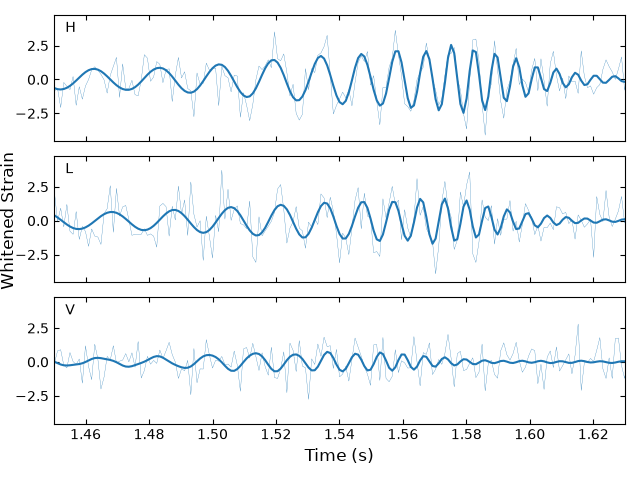

In [15]:
posterior.likelihood.plot_whitened_wf(posterior.likelihood.par_dic_0, trng=xlim);

In [16]:
sampler = cogwheel.sampling.Nautilus(posterior)
# These trade off quality and speed:
sampler.run_kwargs['n_live'] = 1000
sampler.run_kwargs['n_eff'] = 2000

In [17]:
%%time
rundir = sampler.get_rundir(parentdir='pe_runs')
sampler.run(rundir)  # Will take a bit

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


Finished  | 26     | 1        | 4        | 31000    | N/A    | 8271  | +156.31  


CPU times: user 14min 15s, sys: 6.1 s, total: 14min 21s
Wall time: 10min 31s


In [18]:
samples = pd.read_feather(rundir/'samples.feather')
samples

,mchirp,lnq,chieff,cumchidiff,weights,m1,m2,s1z,s2z,l1,...,phi_ref,psi,iota,t_geocenter,lnl_marginalized,lnl,h_h,n_effective,n_qmc,ra
0,72.081345,-1.628249,-0.456734,0.729265,1.422886e-73,198.459815,38.952307,-0.456381,-0.458531,0.0,...,1.956269,2.360362,2.813101,1.467198,2.510814,13.957857,15.429841,6.623449,2048,0.245195
1,92.249919,-2.886880,-0.042736,0.357681,1.314812e-75,527.147002,29.388393,-0.060988,0.284639,0.0,...,2.159744,1.407942,1.276808,1.106064,-2.621798,0.272472,0.019579,15.025722,2048,1.586352
2,111.797492,-1.349255,-0.496470,0.972796,4.381081e-75,263.057958,68.246055,-0.379952,-0.945591,0.0,...,3.937429,2.260289,1.632215,1.303328,-1.373423,2.434450,1.960682,10.009717,2048,1.565024
3,45.440828,-2.862995,-0.692122,0.298206,4.306618e-76,256.034755,14.618948,-0.754685,0.403588,0.0,...,2.925414,1.415486,2.183616,1.313051,-3.025567,-0.070101,0.021366,5.822261,2048,1.097368
4,34.086683,-2.936510,-0.519722,0.786416,1.039525e-75,200.567586,10.640217,-0.516904,-0.572832,0.0,...,4.674930,3.137215,2.303555,1.447005,-1.870035,1.580487,0.331670,11.647795,2048,2.990159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30995,29.457323,-2.768805,0.916123,0.897559,7.248990e-06,157.023458,9.851167,0.990869,-0.275285,0.0,...,1.239952,1.411382,2.593113,1.545673,177.503796,204.595092,373.012671,100.455394,4096,2.113430
30996,29.609023,-2.770959,0.921792,0.890108,8.091744e-06,158.032172,9.893121,0.990867,-0.181621,0.0,...,4.408886,1.370994,3.015965,1.544036,177.608261,206.048340,376.265968,101.406838,4096,2.188068
30997,28.814726,-2.776296,0.896427,0.880136,6.993221e-06,154.276406,9.606591,0.986812,-0.555104,0.0,...,5.512608,2.511994,2.712453,1.546868,177.488609,204.494943,385.493287,53.967666,2048,2.047127
30998,29.388909,-2.772606,0.914629,0.886303,9.130835e-06,157.009407,9.812918,0.989687,-0.286323,0.0,...,1.783276,1.966338,2.663079,1.545853,177.736245,202.617874,341.670647,88.722562,4096,2.119191


In [19]:
list(samples)

['mchirp',
 'lnq',
 'chieff',
 'cumchidiff',
 'weights',
 'm1',
 'm2',
 's1z',
 's2z',
 'l1',
 'l2',
 'f_ref',
 'd_luminosity',
 'dec',
 'lon',
 'phi_ref',
 'psi',
 'iota',
 't_geocenter',
 'lnl_marginalized',
 'lnl',
 'h_h',
 'n_effective',
 'n_qmc',
 'ra']

In [20]:
def add_derived_quantities(samples):
    """
    Add columns inplace to a dataframe of samples.

    Includes redshift, mtot, m1_source, m2_source, mtot_source, chieff, q.
    """
    samples['redshift'] = cogwheel.cosmology.z_of_d_luminosity(samples['d_luminosity'])

    samples['mtot'] = samples['m1'] + samples['m2']

    for mass_key in 'm1', 'm2', 'mtot':
        samples[f'{mass_key}_source'] = samples[mass_key] / (1 + samples['redshift'])

    samples['chieff'] = cogwheel.gw_utils.chieff(**samples[['m1', 'm2', 's1z', 's2z']])

    samples['q'] = samples['m2'] / samples['m1']


add_derived_quantities(samples)

In [21]:
plot_params = [
    # 'mchirp',
    # 'lnq',
    # 'chieff',
    # 'cumchidiff',
    # 'weights',
    'm1',
    'm2',
    's1z',
    's2z',
    # 'l1',
    # 'l2',
    # 'f_ref',
    'd_luminosity',
    'ra',
    'dec',
    # 'lon',
    'phi_ref',
    'psi',
    'iota',
    't_geocenter',
    # 'lnl_marginalized',
    'lnl',
    # 'h_h',
    # 'n_effective',
    # 'n_qmc',
]

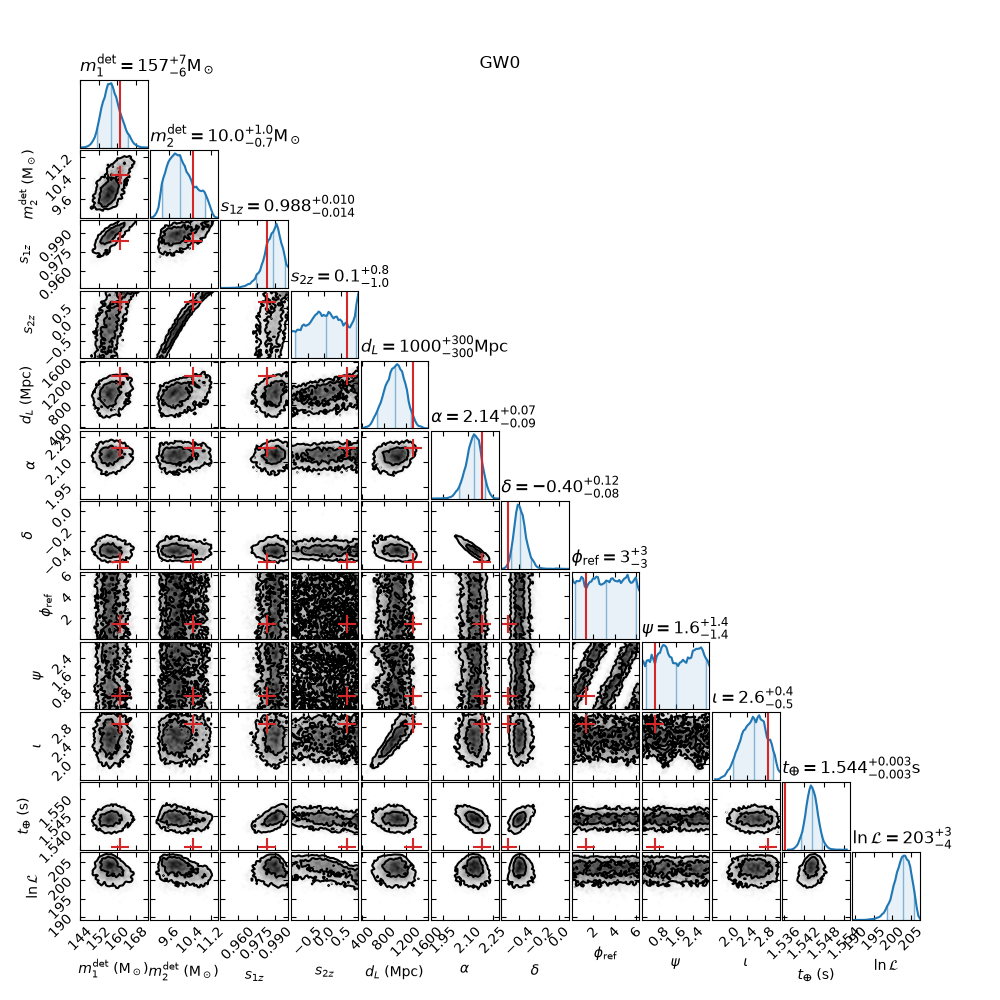

In [22]:
# Note: cogwheel.gw_plotting.CornerPlot understands the weights automatically
corner_plot = cogwheel.gw_plotting.CornerPlot(
    samples, params=plot_params, tail_probability=1e-4
)
corner_plot.plot(title=event_data.eventname)

# Let's also reveal the true (injected) value
corner_plot.scatter_points(event_data.injection['par_dic'], colors=['C3'], s=150,
                           zorder=2, marker='+', adjust_lims=True);

In [23]:
sampler.load_evidence()

{'log_ev': np.float64(156.31391340916474)}

In [24]:

# --- point 2: capture the notebook's numbers for later comparison ---
import json
import numpy as np

def _weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cdf = np.cumsum(weights) - 0.5 * weights
    cdf /= np.sum(weights)
    return float(np.interp(0.5, cdf, values))

_weights = samples['weights'].to_numpy() if 'weights' in samples else np.ones(len(samples))

_medians = {p: _weighted_median(samples[p], _weights) for p in plot_params}

_evidence = sampler.load_evidence()

_par_dic_0 = {k: (float(v) if not isinstance(v, str) else v)
              for k, v in posterior.likelihood.par_dic_0.items()}

# Sanity check against the known minimize_scalar bug: lnl_0 ~ SNR^2 / 2
# for a good reference-waveform fit. A healthy fit should show SNR ~ 24.8;
# the buggy old cogwheel checkout silently produces SNR ~ 3 instead.
_lnl_0 = posterior.likelihood.lnlike(posterior.likelihood.par_dic_0)
_ref_wf_snr = float(np.sqrt(2 * _lnl_0))
print(f"Reference-waveform fit SNR estimate: {_ref_wf_snr:.2f} "
      f"(expect ~24.8; ~3 would mean the minimize_scalar bug is present)")
if _ref_wf_snr < 10:
    raise RuntimeError(
        f"Reference-waveform SNR is {_ref_wf_snr:.2f}, suspiciously low -- "
        "looks like the known minimize_scalar bug. Aborting."
    )

_notebook_numbers = {
    'mchirp_guess': float(mchirp_guess),
    'ref_wf_snr': _ref_wf_snr,
    'par_dic_0': _par_dic_0,
    'plot_params': list(plot_params),
    'medians': _medians,
    'evidence': {'lnZ': float(_evidence[0]), 'lnZ_err': float(_evidence[1])}
                if isinstance(_evidence, tuple) else _evidence,
    'n_samples': int(len(samples)),
    'n_eff_effective': float(np.sum(_weights) ** 2 / np.sum(_weights ** 2)),
}

with open("notebook_numbers.json", "w") as f:
    json.dump(_notebook_numbers, f, indent=2, default=str)

print(json.dumps(_notebook_numbers, indent=2, default=str))


Reference-waveform fit SNR estimate: 18.69 (expect ~24.8; ~3 would mean the minimize_scalar bug is present)
{
  "mchirp_guess": 21.23844134253563,
  "ref_wf_snr": 18.693493405335847,
  "par_dic_0": {
    "d_luminosity": 758.2524954654299,
    "dec": -0.37951463616181685,
    "f_ref": 100.0,
    "iota": 2.141592653589793,
    "l1": 0.0,
    "l2": 0.0,
    "m1": 161.1374687779071,
    "m2": 11.027163055520557,
    "phi_ref": -1.03093296596305,
    "psi": 0.0,
    "ra": 2.1204851620291834,
    "s1x_n": 0.0,
    "s1y_n": 0.0,
    "s1z": 0.989398162125946,
    "s2x_n": 0.0,
    "s2y_n": 0.0,
    "s2z": 0.989398162125946,
    "t_geocenter": 1.542723663874643
  },
  "plot_params": [
    "m1",
    "m2",
    "s1z",
    "s2z",
    "d_luminosity",
    "ra",
    "dec",
    "phi_ref",
    "psi",
    "iota",
    "t_geocenter",
    "lnl"
  ],
  "medians": {
    "m1": 157.2649706841069,
    "m2": 10.011571469518493,
    "s1z": 0.9883919276651429,
    "s2z": 0.054290222560522794,
    "d_luminosity": 10